# Example 2 — Supervised Learning: Classification

Student Academic Risk Prediction

**Student guide:** Run cells in order. Read the comments before modifying code. Document each change when adapting the example to a thesis dataset.


## Pipeline
Synthetic dataset creation -> inspection -> preprocessing -> feature/target definition -> train/test split -> naive baseline -> Logistic Regression -> Decision Tree/KNN/Random Forest comparison -> classification metrics -> confusion matrix -> cross-validation -> introductory tuning -> error interpretation.


In [ ]:
# Import common libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay


In [ ]:
# PHASE 1 — CREATE A SYNTHETIC STUDENT-RISK DATASET
# GUIDE: Import the libraries needed for data handling, preprocessing, modeling, and evaluation.

n=300
df=pd.DataFrame({
 "Student_ID":range(1,n+1),
 "Sex":np.random.choice(["Female","Male"],n),
 "Attendance":np.clip(np.random.normal(82,11,n),45,100).round(1),
 "GPA":np.clip(np.random.normal(2.3,.55,n),1,4).round(2),
 "Study_Hours":np.clip(np.random.normal(8,3,n),1,18).round(1),
 "Failed_Subjects":np.random.choice([0,1,2,3,4],n,p=[.48,.25,.14,.08,.05]),
 "Internet_Access":np.random.choice(["Yes","No"],n,p=[.82,.18])
})
score=((df.Attendance<75).astype(int)*2+(df.GPA>2.75).astype(int)*2+
       (df.Study_Hours<6).astype(int)+(df.Failed_Subjects>=2).astype(int)*2+
       (df.Internet_Access=="No").astype(int))
df["Risk_Status"]=np.where(score+np.random.binomial(1,.15,n)>=3,"At Risk","Not At Risk")
display(df.head())
print(df["Risk_Status"].value_counts())


,Student_ID,Sex,Attendance,GPA,Study_Hours,Failed_Subjects,Internet_Access,Risk_Status
0,1,Female,79.9,2.48,7.9,1,No,Not At Risk
1,2,Male,85.3,1.89,11.3,2,Yes,Not At Risk
2,3,Female,81.6,3.15,8.3,0,Yes,Not At Risk
3,4,Female,69.1,2.36,8.5,0,Yes,Not At Risk
4,5,Female,94.6,2.95,6.9,0,Yes,Not At Risk


Risk_Status
Not At Risk    203
At Risk         97
Name: count, dtype: int64


In [ ]:
# PHASE 2 — INSPECTION
# GUIDE: Inspect the dataset before modeling. Check its size, sample rows, missing values, duplicates, and target balance.

print(df.shape)
print(df.dtypes)
print("\nMissing values:\n",df.isna().sum())
print("\nDuplicates:",df.duplicated().sum())
display(df.describe(include="all"))


(300, 8)
Student_ID           int64
Sex                 object
Attendance         float64
GPA                float64
Study_Hours        float64
Failed_Subjects      int64
Internet_Access     object
Risk_Status         object
dtype: object

Missing values:
 Student_ID         0
Sex                0
Attendance         0
GPA                0
Study_Hours        0
Failed_Subjects    0
Internet_Access    0
Risk_Status        0
dtype: int64

Duplicates: 0


,Student_ID,Sex,Attendance,GPA,Study_Hours,Failed_Subjects,Internet_Access,Risk_Status
count,300.000000,300,300.000000,300.000000,300.000000,300.000000,300,300
unique,NaN,2,NaN,NaN,NaN,NaN,2,2
top,NaN,Female,NaN,NaN,NaN,NaN,Yes,Not At Risk
freq,NaN,151,NaN,NaN,NaN,NaN,248,203
mean,150.500000,NaN,82.276667,2.275767,8.353667,0.953333,NaN,NaN
std,86.746758,NaN,9.910407,0.564777,2.841290,1.175768,NaN,NaN
min,1.000000,NaN,46.300000,1.000000,1.000000,0.000000,NaN,NaN
25%,75.750000,NaN,74.475000,1.877500,6.300000,0.000000,NaN,NaN
50%,150.500000,NaN,82.850000,2.265000,8.450000,1.000000,NaN,NaN
75%,225.250000,NaN,89.350000,2.650000,10.100000,1.000000,NaN,NaN


In [ ]:
# PHASE 3 — DEFINE FEATURES (X) AND TARGET (y)
# GUIDE:
# X contains the input variables that the model will use for prediction.
# y contains the target or class that we want the model to predict.

# Student_ID is excluded because it is only an identifier.
# Risk_Status is excluded from X because it is the target variable.

X = df[
    [
        "Sex",
        "Attendance",
        "GPA",
        "Study_Hours",
        "Failed_Subjects",
        "Internet_Access"
    ]
].copy()

y = df["Risk_Status"].copy()

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features (X):


,Sex,Attendance,GPA,Study_Hours,Failed_Subjects,Internet_Access
0,Female,79.9,2.48,7.9,1,No
1,Male,85.3,1.89,11.3,2,Yes
2,Female,81.6,3.15,8.3,0,Yes
3,Female,69.1,2.36,8.5,0,Yes
4,Female,94.6,2.95,6.9,0,Yes



Target (y):


,Risk_Status
0,Not At Risk
1,Not At Risk
2,Not At Risk
3,Not At Risk
4,Not At Risk



Shape of X: (300, 6)
Shape of y: (300,)

Target distribution:
Risk_Status
Not At Risk    203
At Risk         97
Name: count, dtype: int64


In [ ]:
# PHASE 3B — CREATE THE PREPROCESSING PIPELINE

# GUIDE:
# Numerical and categorical variables require different preprocessing.
#
# Numerical features:
#   - Attendance
#   - GPA
#   - Study_Hours
#   - Failed_Subjects
#
# Categorical features:
#   - Sex
#   - Internet_Access
#
# StandardScaler standardizes numerical variables.
# OneHotEncoder converts categorical values into numerical form.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "Attendance",
    "GPA",
    "Study_Hours",
    "Failed_Subjects"
]

categorical_features = [
    "Sex",
    "Internet_Access"
]

prep = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline successfully created.")
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline successfully created.
Numerical features: ['Attendance', 'GPA', 'Study_Hours', 'Failed_Subjects']
Categorical features: ['Sex', 'Internet_Access']


In [ ]:
# PHASE 4 — TRAIN / VALIDATION / TEST SPLIT
# GUIDE: We will use 60% Training, 20% Validation, and 20% Testing.
# GUIDE: Training data teaches the model.
# GUIDE: Validation data helps compare models and select settings.
# GUIDE: Test data remains untouched until the FINAL evaluation.
# GUIDE: stratify=y helps preserve the At Risk / Not At Risk proportions.

# STEP 1:
# Keep 60% for training and temporarily hold out 40%.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# STEP 2:
# Divide the temporary 40% equally:
# 20% of the original data becomes validation,
# 20% of the original data becomes testing.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Total records:", len(X))
print("Training records:", len(X_train))
print("Validation records:", len(X_val))
print("Testing records:", len(X_test))

print("\nPercentage of total dataset:")
print("Training:", round(len(X_train)/len(X)*100, 1), "%")
print("Validation:", round(len(X_val)/len(X)*100, 1), "%")
print("Testing:", round(len(X_test)/len(X)*100, 1), "%")

print("\nClass distribution:")
print("Training:\n", y_train.value_counts())
print("\nValidation:\n", y_val.value_counts())
print("\nTesting:\n", y_test.value_counts())


Total records: 300
Training records: 180
Validation records: 60
Testing records: 60

Percentage of total dataset:
Training: 60.0 %
Validation: 20.0 %
Testing: 20.0 %

Class distribution:
Training:
 Risk_Status
Not At Risk    122
At Risk         58
Name: count, dtype: int64

Validation:
 Risk_Status
Not At Risk    41
At Risk        19
Name: count, dtype: int64

Testing:
 Risk_Status
Not At Risk    40
At Risk        20
Name: count, dtype: int64


### Understanding the 60/20/20 split

This version deliberately uses three fixed subsets:

- **60% Training** — the model learns from these records.
- **20% Validation** — used during development to compare algorithms and tune settings.
- **20% Testing** — held aside until the final model has been selected.

For the synthetic dataset of **300 student records**, this produces **180 training, 60 validation, and 60 testing records**.

The validation set may be examined repeatedly during development. The test set should remain untouched until the final evaluation.


In [ ]:
# PHASE 5 — TRAIN MODELS AND COMPARE USING VALIDATION DATA
# GUIDE: Every model learns ONLY from X_train and y_train.
# GUIDE: We then evaluate candidate models using the validation set.
# GUIDE: Do NOT use the test set yet.
# GUIDE: Dummy is our naive baseline.

models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42)
}

validation_rows = []
fitted = {}

for name, model in models.items():
    # Pipeline keeps preprocessing and the model together.
    pipe = Pipeline([
        ("prep", prep),
        ("model", model)
    ])

    # TRAINING: learn from the 60% training set only.
    pipe.fit(X_train, y_train)

    # VALIDATION: predict the separate 20% validation set.
    val_pred = pipe.predict(X_val)

    fitted[name] = pipe

    validation_rows.append([
        name,
        accuracy_score(y_val, val_pred),
        precision_score(y_val, val_pred, pos_label="At Risk", zero_division=0),
        recall_score(y_val, val_pred, pos_label="At Risk", zero_division=0),
        f1_score(y_val, val_pred, pos_label="At Risk", zero_division=0)
    ])

validation_results = pd.DataFrame(
    validation_rows,
    columns=["Model", "Validation Accuracy", "Precision", "Recall", "F1"]
)

print("MODEL PERFORMANCE ON VALIDATION DATA")
display(validation_results.round(3).sort_values("F1", ascending=False))

# GUIDE:
# Validation results are used for model comparison/development.
# A higher score is better, but choose metrics based on the research objective.
# For academic-risk classification, Recall is important when missing an At Risk
# student has greater consequences than unnecessarily flagging a student.


MODEL PERFORMANCE ON VALIDATION DATA


,Model,Validation Accuracy,Precision,Recall,F1
1,Logistic Regression,0.917,0.850,0.895,0.872
2,Decision Tree,0.883,1.000,0.632,0.774
4,Random Forest,0.817,0.750,0.632,0.686
3,KNN,0.833,0.909,0.526,0.667
0,Dummy,0.683,0.000,0.000,0.000


### How to interpret the model-comparison results

Use the metrics according to the research problem:

- **Accuracy** — proportion of all test cases predicted correctly.
- **Precision (At Risk)** — among students predicted *At Risk*, how many are actually At Risk?
- **Recall (At Risk)** — among all truly *At Risk* students, how many did the model identify?
- **F1-score** — balances precision and recall.

For an academic-risk application, **recall deserves particular attention** because low recall means more truly At Risk students are missed. However, the appropriate metric should ultimately follow the research objective and consequences of each error type.

The **Dummy** result is the baseline reference. A learned model should be interpreted relative to that starting point.


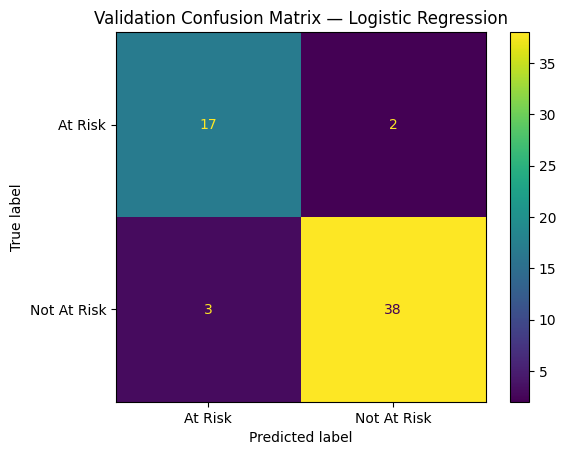

VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

     At Risk       0.85      0.89      0.87        19
 Not At Risk       0.95      0.93      0.94        41

    accuracy                           0.92        60
   macro avg       0.90      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60

Sample validation predictions:


,Sex,Attendance,GPA,Study_Hours,Failed_Subjects,Internet_Access,Actual,Predicted,Correct?
189,Male,88.7,3.05,11.8,0,Yes,Not At Risk,Not At Risk,True
78,Female,84.4,2.34,8.8,0,Yes,Not At Risk,Not At Risk,True
72,Female,87.2,1.94,10.5,4,Yes,Not At Risk,Not At Risk,True
203,Female,78.6,2.70,8.6,3,Yes,At Risk,At Risk,True
142,Male,95.9,2.03,5.5,0,Yes,Not At Risk,Not At Risk,True
136,Female,68.1,2.35,6.1,2,Yes,At Risk,At Risk,True
183,Female,85.4,1.76,8.4,2,Yes,Not At Risk,Not At Risk,True
279,Male,100.0,2.64,6.0,1,Yes,Not At Risk,Not At Risk,True
91,Male,71.7,2.03,7.1,2,Yes,At Risk,At Risk,True
0,Female,79.9,2.48,7.9,1,No,Not At Risk,At Risk,False



Misclassified validation records:


,Sex,Attendance,GPA,Study_Hours,Failed_Subjects,Internet_Access,Actual,Predicted,Correct?
0,Female,79.9,2.48,7.9,1,No,Not At Risk,At Risk,False
19,Female,87.2,2.69,2.9,1,Yes,Not At Risk,At Risk,False
284,Male,80.7,2.81,6.3,0,Yes,At Risk,Not At Risk,False
240,Male,81.8,3.72,7.8,1,Yes,Not At Risk,At Risk,False
297,Female,69.6,2.25,8.6,0,Yes,At Risk,Not At Risk,False


In [ ]:
# PHASE 6 — VALIDATION CONFUSION MATRIX AND ERROR ANALYSIS
# GUIDE: At this stage, the confusion matrix uses VALIDATION data.
# GUIDE: This helps us understand errors while developing/selecting the model.
# GUIDE: The test set is still untouched.

# Logistic Regression is used here as the teaching candidate.
candidate = fitted["Logistic Regression"]
val_pred = candidate.predict(X_val)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred,
    labels=["At Risk", "Not At Risk"]
)
plt.title("Validation Confusion Matrix — Logistic Regression")
plt.show()

print("VALIDATION CLASSIFICATION REPORT")
print(classification_report(y_val, val_pred, zero_division=0))

# Show validation records together with their actual and predicted classes.
validation_check = X_val.copy()
validation_check["Actual"] = y_val.values
validation_check["Predicted"] = val_pred
validation_check["Correct?"] = validation_check["Actual"] == validation_check["Predicted"]

print("Sample validation predictions:")
display(validation_check.head(15))

print("\nMisclassified validation records:")
display(validation_check[validation_check["Correct?"] == False])

# GUIDE:
# True Positive  = actual At Risk, predicted At Risk
# False Negative = actual At Risk, predicted Not At Risk
# False Positive = actual Not At Risk, predicted At Risk
# True Negative  = actual Not At Risk, predicted Not At Risk
#
# Ask: Which error is more important for the intended application?


### How to read the confusion matrix

For binary academic-risk classification, interpret the cells conceptually as:

| Actual condition | Predicted At Risk | Predicted Not at Risk |
|---|---|---|
| **At Risk** | **True Positive (TP):** correctly identified At Risk | **False Negative (FN):** At Risk student was missed |
| **Not at Risk** | **False Positive (FP):** unnecessary At Risk flag | **True Negative (TN):** correctly identified Not at Risk |

The **diagonal cells are correct predictions**; off-diagonal cells are mistakes.

A **False Negative** can be especially important in this example because a student who actually needs support could be classified as Not at Risk. A **False Positive** may lead to unnecessary intervention. Students should explain which error matters more for their own thesis context rather than simply reporting the matrix.


In [ ]:
# PHASE 7 — HYPERPARAMETER TUNING USING THE VALIDATION SET
# GUIDE: Instead of cross-validation, we explicitly use X_val and y_val.
# GUIDE: Each Decision Tree is trained on the SAME training set.
# GUIDE: Different max_depth values are compared on the SAME validation set.
# GUIDE: The test set remains untouched.

depth_results = []

for depth in [2, 3, 4, 5, 8, None]:
    tree_pipe = Pipeline([
        ("prep", prep),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    # Train using training data.
    tree_pipe.fit(X_train, y_train)

    # Evaluate the setting using validation data.
    val_pred_tree = tree_pipe.predict(X_val)

    depth_results.append([
        str(depth),
        accuracy_score(y_val, val_pred_tree),
        precision_score(y_val, val_pred_tree, pos_label="At Risk", zero_division=0),
        recall_score(y_val, val_pred_tree, pos_label="At Risk", zero_division=0),
        f1_score(y_val, val_pred_tree, pos_label="At Risk", zero_division=0)
    ])

depth_table = pd.DataFrame(
    depth_results,
    columns=["max_depth", "Accuracy", "Precision", "Recall", "F1"]
)

print("DECISION TREE SETTINGS — VALIDATION RESULTS")
display(depth_table.round(3).sort_values("F1", ascending=False))

# Select the setting with the highest validation F1 for this demonstration.
best_depth_text = depth_table.loc[depth_table["F1"].idxmax(), "max_depth"]
best_depth = None if best_depth_text == "None" else int(best_depth_text)

print("Selected max_depth based on Validation F1:", best_depth_text)

# TEACHING POINT:
# We are allowed to inspect validation performance and change settings.
# We should NOT repeatedly inspect the test set while tuning.


DECISION TREE SETTINGS — VALIDATION RESULTS


,max_depth,Accuracy,Precision,Recall,F1
4,8,0.900,0.882,0.789,0.833
5,None,0.900,0.882,0.789,0.833
3,5,0.883,1.000,0.632,0.774
2,4,0.800,0.706,0.632,0.667
1,3,0.783,0.688,0.579,0.629
0,2,0.700,0.520,0.684,0.591


Selected max_depth based on Validation F1: 8


### How validation replaces cross-validation in this version

This notebook intentionally **does not use k-fold cross-validation**. Instead, it uses one fixed validation set.

The model is trained using the training set, then candidate algorithms or parameter settings are evaluated using the validation set. Once development is complete, the selected configuration is evaluated on the untouched test set.

This makes the roles of **Training → Validation → Testing** especially visible for introductory teaching.


FINAL TEST RESULTS
------------------
Accuracy : 0.95
Precision: 0.905
Recall   : 0.95
F1       : 0.927

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

     At Risk       0.90      0.95      0.93        20
 Not At Risk       0.97      0.95      0.96        40

    accuracy                           0.95        60
   macro avg       0.94      0.95      0.94        60
weighted avg       0.95      0.95      0.95        60



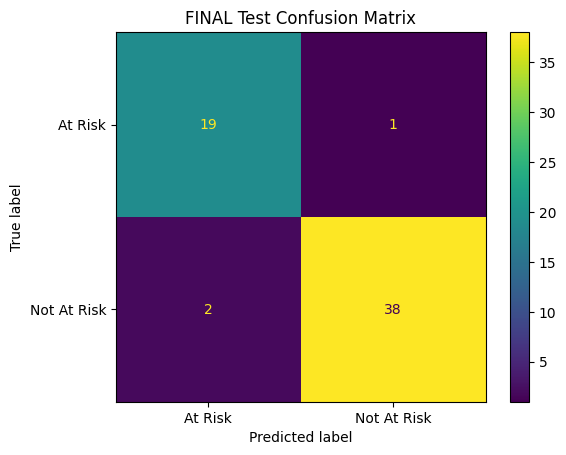

In [ ]:
# PHASE 8 — FINAL MODEL AND ONE-TIME TEST EVALUATION
# GUIDE: Model development is now finished.
# GUIDE: We selected the Decision Tree max_depth using VALIDATION data.
# GUIDE: We can now combine Training + Validation data to fit the final model.
# GUIDE: The untouched TEST set is used only now for final evaluation.

# Combine training and validation records.
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

final_model = Pipeline([
    ("prep", prep),
    ("model", DecisionTreeClassifier(
        max_depth=best_depth,
        random_state=42
    ))
])

# Train the final configuration using all development data (Train + Validation).
final_model.fit(X_train_final, y_train_final)

# FINAL TEST:
# These records were not used for training, model comparison, or tuning.
test_pred = final_model.predict(X_test)

print("FINAL TEST RESULTS")
print("------------------")
print("Accuracy :", round(accuracy_score(y_test, test_pred), 3))
print("Precision:", round(precision_score(y_test, test_pred, pos_label="At Risk", zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, test_pred, pos_label="At Risk", zero_division=0), 3))
print("F1       :", round(f1_score(y_test, test_pred, pos_label="At Risk", zero_division=0), 3))

print("\nFINAL TEST CLASSIFICATION REPORT")
print(classification_report(y_test, test_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    labels=["At Risk", "Not At Risk"]
)
plt.title("FINAL Test Confusion Matrix")
plt.show()

# GUIDE:
# The sum of all confusion-matrix cells should equal the number of TEST records.
# With 300 total records and a 60/20/20 split:
# Training = 180, Validation = 60, Test = 60.
#
# The final test results estimate performance on unseen held-out data.


## Thesis adaptation
Replace the synthetic data with the thesis dataset. Document the unit of analysis, target definition, feature justification, preprocessing, split strategy, baseline, alternative models, metric choice, error consequences, leakage risks, and next experiment.


## PHASE 9 — Interactive Academic Risk Prediction

This section allows the **user/student to enter a new student profile**. The trained Logistic Regression pipeline then predicts either:

- **At Risk**
- **Not At Risk**

The required inputs exactly match the model features used earlier: **Sex, Attendance, GPA, Study Hours, Failed Subjects, and Internet Access**.

> **Teaching note:** This is a synthetic classroom model. Its prediction demonstrates how a classification model can accept new input and produce a class label. It should **not** be used to make real academic decisions about students without appropriate real-world validation, institutional safeguards, and human review.


In [ ]:
# PHASE 9 — INTERACTIVE USER INPUT AND RISK PREDICTION
# GUIDE: Run this cell after all earlier model-training cells have been executed.
# GUIDE: Enter one new student's information when prompted.
# GUIDE: The values are placed into a one-row DataFrame with the SAME features used during training.
# GUIDE: The already-trained pipeline automatically applies preprocessing before prediction.

print("ACADEMIC RISK PREDICTION")
print("------------------------")

# Ask for categorical information.
# Validation loops prevent unsupported entries.
while True:
    sex = input("Sex (Female/Male): ").strip().title()
    if sex in ["Female", "Male"]:
        break
    print("Please enter Female or Male.")

while True:
    internet = input("Internet Access (Yes/No): ").strip().title()
    if internet in ["Yes", "No"]:
        break
    print("Please enter Yes or No.")

# Ask for numerical information and check reasonable input ranges.
while True:
    try:
        attendance = float(input("Attendance percentage (0-100): "))
        if 0 <= attendance <= 100:
            break
        print("Attendance must be between 0 and 100.")
    except ValueError:
        print("Please enter a numerical value.")

while True:
    try:
        gpa = float(input("GPA (1.00-4.00): "))
        if 1.00 <= gpa <= 4.00:
            break
        print("GPA must be between 1.00 and 4.00.")
    except ValueError:
        print("Please enter a numerical value.")

while True:
    try:
        study_hours = float(input("Study hours per week (0 or higher): "))
        if study_hours >= 0:
            break
        print("Study hours cannot be negative.")
    except ValueError:
        print("Please enter a numerical value.")

while True:
    try:
        failed_subjects = int(input("Number of failed subjects (0 or higher): "))
        if failed_subjects >= 0:
            break
        print("Failed subjects cannot be negative.")
    except ValueError:
        print("Please enter a whole number.")

# IMPORTANT:
# The column names below must exactly match the features used to train the model.
new_student = pd.DataFrame({
    "Sex": [sex],
    "Attendance": [attendance],
    "GPA": [gpa],
    "Study_Hours": [study_hours],
    "Failed_Subjects": [failed_subjects],
    "Internet_Access": [internet]
})

print("\nEntered Student Profile:")
display(new_student)

# 'final_model' is the final Decision Tree pipeline trained after validation.
# Because preprocessing is inside the pipeline, we can directly pass the raw feature values.
risk_prediction = final_model.predict(new_student)[0]

print("\nPREDICTED RISK STATUS:", risk_prediction)

# Logistic Regression also provides class probabilities.
# This is useful for demonstrating how strongly the model favors each class.
if hasattr(final_model.named_steps["model"], "predict_proba"):
    probabilities = final_model.predict_proba(new_student)[0]
    classes = final_model.named_steps["model"].classes_

    probability_table = pd.DataFrame({
        "Risk Status": classes,
        "Predicted Probability": probabilities
    })

    probability_table["Predicted Probability"] = (
        probability_table["Predicted Probability"] * 100
    ).round(2).astype(str) + "%"

    print("\nModel Probability Output:")
    display(probability_table)

print("\nNOTE:")
print("This result is produced by a synthetic teaching model.")
print("It is not a validated academic-risk assessment for real students.")


### How to interpret the interactive result

The **Predicted Risk Status** is the class selected by the trained Logistic Regression model from the information entered by the user.

The probability table provides additional context. For example, if the model produces:

| Risk Status | Predicted Probability |
|---|---:|
| At Risk | 78% |
| Not At Risk | 22% |

the model assigns the entered profile more strongly to **At Risk**. This does **not** mean there is a scientifically established “78% chance” that a real student will experience academic difficulty. In this exercise, the probability is the fitted model's estimated class probability based on the synthetic training data.

### Questions for students

After trying several profiles, observe what happens when you change **one variable at a time**:

1. Keep everything the same and lower Attendance.
2. Restore Attendance and increase Failed Subjects.
3. Change Internet Access from Yes to No.
4. Increase or decrease Study Hours.
5. Change GPA while keeping the other features fixed.

Ask: **Did the predicted class or probability change? Why might the model respond that way?**

This provides a simple introduction to **model sensitivity and interpretation** without treating the prediction as a real-world academic judgment.


## Student Interpretation Guide

After running the notebook, answer briefly:

1. How many records were assigned to Training, Validation, and Testing?
2. What is the purpose of each subset?
3. What was the Dummy baseline performance on the validation set?
4. Which learned models improved over the baseline?
5. Which model had the strongest validation Recall and F1?
6. What do False Negatives mean in an academic-risk application?
7. What do False Positives mean?
8. Which `max_depth` was selected using validation data?
9. What were the final metrics on the previously untouched test set?
10. Did the final test performance differ from validation performance? What might explain the difference?
11. Why should the test set not be repeatedly used while tuning the model?
12. What limitations should be considered before applying such a model to real students?

### Thesis-writing reminder
Clearly distinguish **validation results used during model development** from **final test results used to estimate generalization to unseen held-out data**.
